<a href="https://colab.research.google.com/github/GuilhermeMBertolo/CIC_IDS2017/blob/main/CIC_IDS_2017_Regressao_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIC-IDS-2017 | Regressao Logistica

In [ ]:
# =====================================================
# 1. Ambiente e configuracao experimental
# =====================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

SEED = 314159
np.random.seed(SEED)

PASTA = '/content/drive/MyDrive/CIC-IDS-2017/'
ARQUIVOS = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

NOMES_CLASSES = [
    'BENIGN', 'DoS', 'DDoS', 'Brute Force',
    'Web Attack', 'Reconnaissance', 'Bot', 'Raros',
]


In [ ]:
# =====================================================
# 2. Carga, limpeza e agrupamento das classes
# =====================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ambiente local detectado. Ajuste PASTA para a pasta dos CSVs.')


def carregar_e_preparar(pasta, arquivos):
    tabelas = []
    for arquivo in arquivos:
        dados = pd.read_csv(os.path.join(pasta, arquivo), low_memory=False)
        dados.columns = dados.columns.str.strip()
        tabelas.append(dados)

    df = pd.concat(tabelas, ignore_index=True)
    df['Label'] = df['Label'].replace({
        'Web Attack Ã¯Â¿Â½ Brute Force': 'Web Attack - Brute Force',
        'Web Attack Ã¯Â¿Â½ Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack Ã¯Â¿Â½ XSS': 'Web Attack - XSS',
        'Web Attack � Brute Force': 'Web Attack - Brute Force',
        'Web Attack � Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack � XSS': 'Web Attack - XSS',
    })

    antes = len(df)
    df = df.dropna()
    colunas_numericas = df.select_dtypes(include=np.number).columns
    df = df.loc[np.isfinite(df[colunas_numericas]).all(axis=1)]
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Linhas removidas na limpeza: {antes - len(df):,}')

    grupos = {
        'BENIGN': 'BENIGN',
        'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
        'DoS Slowhttptest': 'DoS', 'DoS slowloris': 'DoS',
        'DDoS': 'DDoS',
        'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
        'Web Attack - Brute Force': 'Web Attack',
        'Web Attack - Sql Injection': 'Web Attack',
        'Web Attack - XSS': 'Web Attack',
        'PortScan': 'Reconnaissance', 'Bot': 'Bot',
        'Infiltration': 'Raros', 'Heartbleed': 'Raros',
    }
    codigos = {nome: indice for indice, nome in enumerate(NOMES_CLASSES)}

    df['Label_grupo'] = df['Label'].map(grupos)
    df = df.dropna(subset=['Label_grupo']).copy()
    df['Label_final'] = df['Label_grupo'].map(codigos).astype(int)

    X = df.drop(columns=['Label', 'Label_grupo', 'Label_final'])
    y = df['Label_final']
    print(f'Dataset final: {X.shape[0]:,} linhas e {X.shape[1]} atributos')
    display(df['Label_grupo'].value_counts().reindex(NOMES_CLASSES).to_frame('quantidade'))
    return X, y


Mounted at /content/drive


In [ ]:
# =====================================================
# 3. Divisao estratificada: 80% treino, 10% validacao, 10% teste
# =====================================================

X, y = carregar_e_preparar(PASTA, ARQUIVOS)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED, shuffle=True,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED, shuffle=True,
)

resumo_divisao = pd.DataFrame({
    'Conjunto': ['Treino', 'Validacao', 'Teste'],
    'Linhas': [len(X_train), len(X_val), len(X_test)],
    'Percentual': [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
})
resumo_divisao['Percentual'] = (resumo_divisao['Percentual'] * 100).round(2)
display(resumo_divisao)


Linhas removidas na limpeza: 309,945
Dataset final: 2,520,798 linhas e 78 atributos


,quantidade
Label_grupo,
BENIGN,2095057
DoS,193745
DDoS,128014
Brute Force,9150
Web Attack,2143
Reconnaissance,90694
Bot,1948
Raros,47


,Conjunto,Linhas,Percentual
0,Treino,2016638,80.0
1,Validacao,252080,10.0
2,Teste,252080,10.0


In [ ]:
# =====================================================
# 4. Selecao de atributos por importancia do XGBoost
# =====================================================

# Mesmo criterio de selecao usado no MLP de referencia: 95% da importancia acumulada.
seletor_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(NOMES_CLASSES),
    eval_metric='mlogloss',
    random_state=SEED,
    tree_method='hist',
    n_estimators=200,
    learning_rate=0.10,
    max_depth=6,
    n_jobs=-1,
)
seletor_xgb.fit(X_train, y_train)

importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': seletor_xgb.feature_importances_,
}).sort_values('Importance', ascending=False)
importancias['Importancia_acumulada'] = importancias['Importance'].cumsum() / importancias['Importance'].sum()

features_selecionadas = importancias.loc[
    importancias['Importancia_acumulada'] <= 0.95,
    'Feature',
].tolist()

if not features_selecionadas:
    features_selecionadas = [importancias.iloc[0]['Feature']]

print(f'Features selecionadas: {len(features_selecionadas)}')
display(importancias.head(20))


Features selecionadas: 21


,Feature,Importance,Importancia_acumulada
13,Bwd Packet Length Std,0.213418,0.213418
74,Idle Mean,0.134505,0.347923
76,Idle Max,0.116660,0.464584
12,Bwd Packet Length Mean,0.061026,0.525610
30,Fwd PSH Flags,0.054695,0.580304
68,act_data_pkt_fwd,0.053228,0.633532
52,Average Packet Size,0.050233,0.683766
4,Total Length of Fwd Packets,0.044570,0.728336
14,Flow Bytes/s,0.031720,0.760056
35,Bwd Header Length,0.031349,0.791405


In [ ]:
# =====================================================
# 5. Normalizacao ajustada somente no treino
# =====================================================

scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train[features_selecionadas])
X_val_z = scaler.transform(X_val[features_selecionadas])
X_test_z = scaler.transform(X_test[features_selecionadas])


In [ ]:
# =====================================================
# 6. Escolha rapida de C no conjunto de validacao
# =====================================================

# A escolha de C usa amostras estratificadas para evitar treinar varias
# regressoes logisticas completas. O teste final continua isolado.
MAX_TREINO_BUSCA_C = 100_000
MAX_VALIDACAO_BUSCA_C = 50_000


def amostra_estratificada_array(X_array, y_array, max_linhas, seed):
    y_array = np.asarray(y_array)
    if max_linhas is None or len(y_array) <= max_linhas:
        return X_array, y_array

    indices = np.arange(len(y_array))
    indices_amostra, _ = train_test_split(
        indices,
        train_size=max_linhas,
        stratify=y_array,
        random_state=seed,
        shuffle=True,
    )
    return X_array[indices_amostra], y_array[indices_amostra]


X_train_c, y_train_c = amostra_estratificada_array(
    X_train_z, y_train.to_numpy(), MAX_TREINO_BUSCA_C, SEED,
)
X_val_c, y_val_c = amostra_estratificada_array(
    X_val_z, y_val.to_numpy(), MAX_VALIDACAO_BUSCA_C, SEED + 1,
)

print(f'Amostra para busca de C: {len(X_train_c):,} treino e {len(X_val_c):,} validacao')

valores_c = [0.1, 1.0, 10.0]
resultados_validacao = []

for c in valores_c:
    modelo = LogisticRegression(
        C=c,
        class_weight='balanced',
        solver='saga',
        penalty='l2',
        max_iter=300,
        tol=2e-3,
        n_jobs=-1,
        random_state=SEED,
    )
    modelo.fit(X_train_c, y_train_c)
    pred_val = modelo.predict(X_val_c)
    resultados_validacao.append({
        'C': c,
        'Accuracy': accuracy_score(y_val_c, pred_val),
        'F1_weighted': f1_score(y_val_c, pred_val, average='weighted', zero_division=0),
        'F1_macro': f1_score(y_val_c, pred_val, average='macro', zero_division=0),
    })

tabela_validacao = pd.DataFrame(resultados_validacao).sort_values('Accuracy', ascending=False)
display(tabela_validacao.style.format({'Accuracy': '{:.4f}', 'F1_weighted': '{:.4f}', 'F1_macro': '{:.4f}'}))

melhor_c = tabela_validacao.iloc[0]['C']
print(f'Melhor C pela acuracia de validacao: {melhor_c}')


Amostra para busca de C: 100,000 treino e 50,000 validacao


,C,Accuracy,F1_weighted,F1_macro
2,10.000000,0.6303,0.7228,0.3518
1,1.000000,0.6299,0.7225,0.3516
0,0.100000,0.6276,0.7204,0.3504


Melhor C pela acuracia de validacao: 10.0


In [ ]:
# =====================================================
# 7. Treino final balanceado e avaliacao no teste isolado
# =====================================================

# Meio termo entre qualidade e tempo:
# - treina com treino + validacao apos a escolha de C;
# - usa uma amostra estratificada grande para evitar execucoes de varias horas;
# - avalia no teste completo e isolado.
MAX_TREINO_FINAL_LOGISTICA = 400_000

X_modelo = np.vstack([X_train_z, X_val_z])
y_modelo = np.concatenate([y_train.to_numpy(), y_val.to_numpy()])

X_modelo_log, y_modelo_log = amostra_estratificada_array(
    X_modelo,
    y_modelo,
    MAX_TREINO_FINAL_LOGISTICA,
    SEED + 2,
)

print(f'Amostra usada no treino final: {len(X_modelo_log):,} de {len(X_modelo):,} linhas')

logistica_final = LogisticRegression(
    C=melhor_c,
    class_weight='balanced',
    solver='saga',
    penalty='l2',
    max_iter=500,
    tol=1e-3,
    n_jobs=-1,
    random_state=SEED,
)
logistica_final.fit(X_modelo_log, y_modelo_log)
y_pred = logistica_final.predict(X_test_z)

print(f'Regressao logistica treinada. C escolhido: {melhor_c}')

metricas = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision weighted', 'Recall weighted', 'F1 weighted', 'F1 macro', 'Balanced accuracy'],
    'Valor': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        balanced_accuracy_score(y_test, y_pred),
    ],
})
metricas['Valor (%)'] = (metricas['Valor'] * 100).round(2)
display(metricas[['Metrica', 'Valor (%)']])

print(classification_report(
    y_test, y_pred, labels=range(len(NOMES_CLASSES)),
    target_names=NOMES_CLASSES, digits=4, zero_division=0,
))


Amostra usada no treino final: 400,000 de 2,268,718 linhas
Regressao logistica treinada. C escolhido: 10.0


,Metrica,Valor (%)
0,Accuracy,62.17
1,Precision weighted,93.14
2,Recall weighted,62.17
3,F1 weighted,71.58
4,F1 macro,34.63
5,Balanced accuracy,74.56


                precision    recall  f1-score   support

        BENIGN     0.9990    0.5700    0.7259    209506
           DoS     0.7560    0.8445    0.7978     19374
          DDoS     0.7059    0.8471    0.7701     12802
   Brute Force     0.0618    0.9749    0.1162       915
    Web Attack     0.0145    0.8977    0.0285       215
Reconnaissance     0.1935    0.9857    0.3235      9070
           Bot     0.0038    0.3454    0.0075       194
         Raros     0.0005    0.5000    0.0010         4

      accuracy                         0.6217    252080
     macro avg     0.3419    0.7456    0.3463    252080
  weighted avg     0.9314    0.6217    0.7158    252080



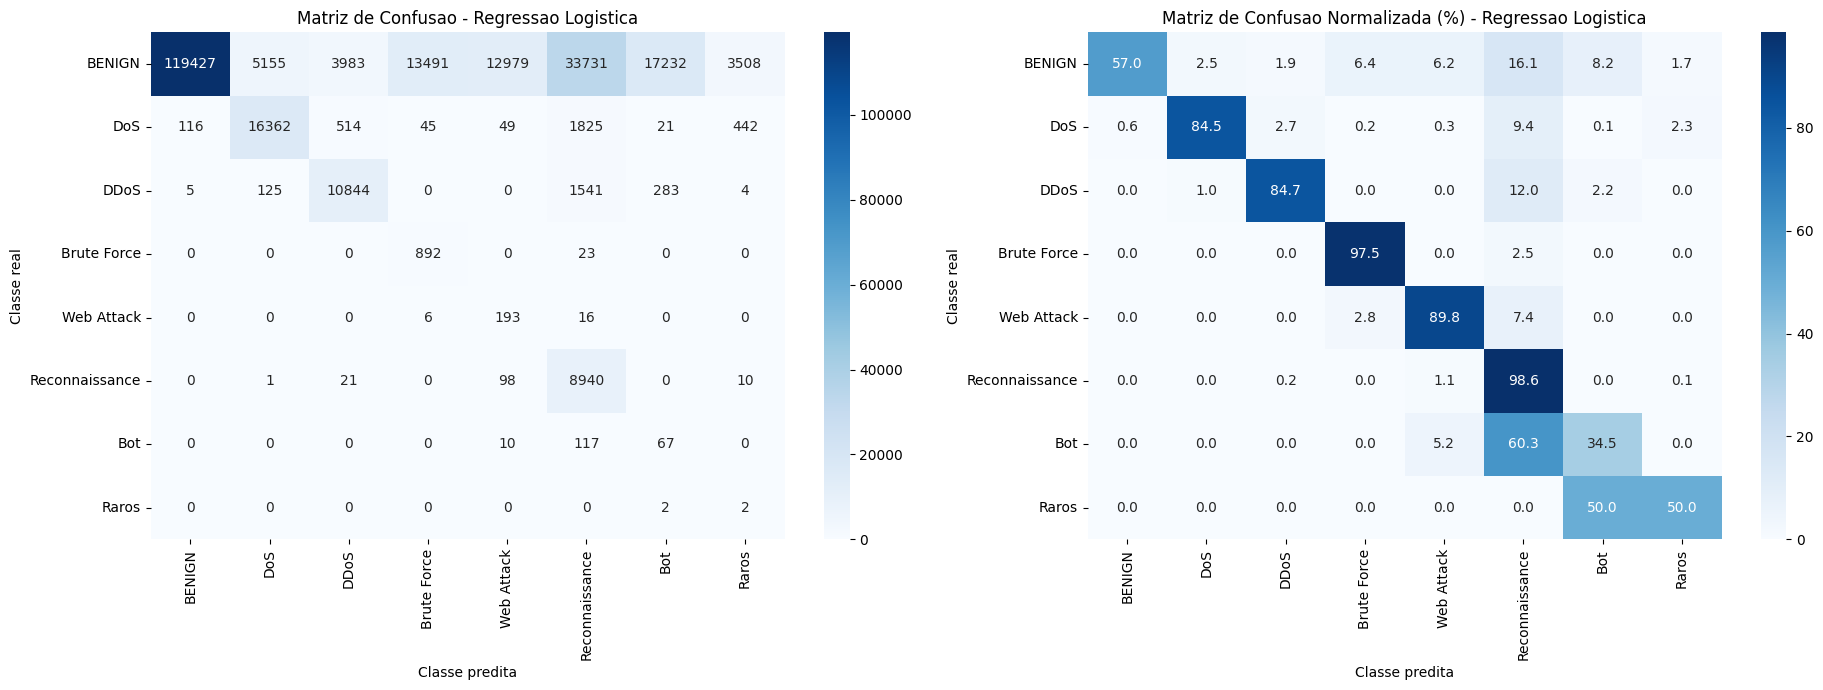

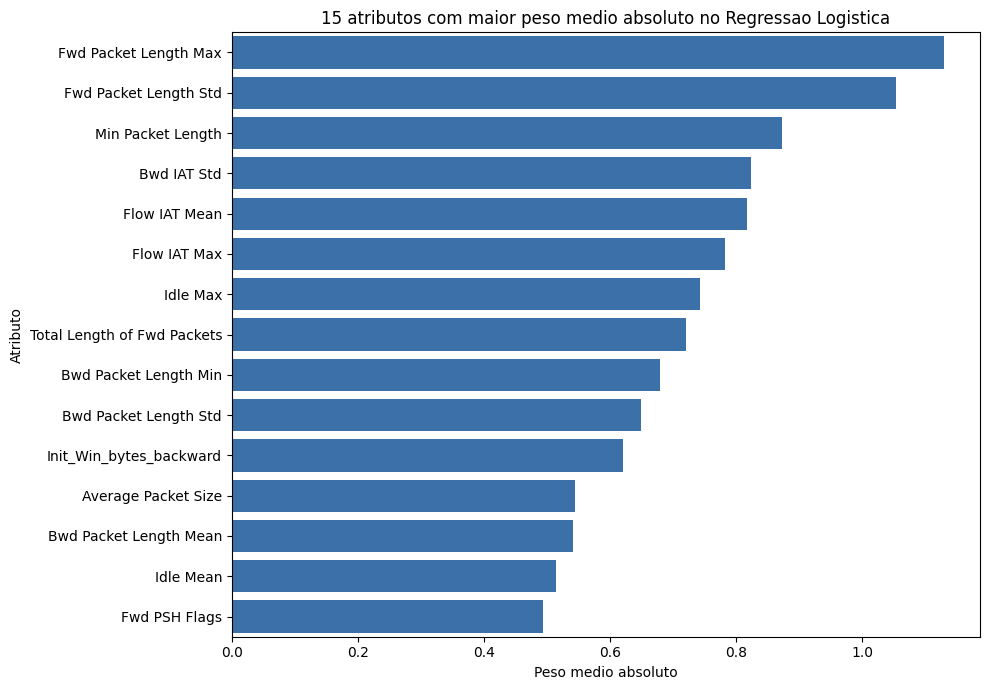

In [ ]:
# =====================================================
# 8. Analise visual e interpretacao do modelo
# =====================================================

cm = confusion_matrix(y_test, y_pred, labels=range(len(NOMES_CLASSES)))
cm_percent = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
sns.heatmap(pd.DataFrame(cm, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set(title='Matriz de Confusao - Regressao Logistica', xlabel='Classe predita', ylabel='Classe real')

sns.heatmap(pd.DataFrame(cm_percent, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set(title='Matriz de Confusao Normalizada (%) - Regressao Logistica', xlabel='Classe predita', ylabel='Classe real')
plt.tight_layout()
plt.show()

coeficientes = pd.DataFrame({
    'Feature': features_selecionadas,
    'Importancia_media': np.mean(np.abs(logistica_final.coef_), axis=0),
}).sort_values('Importancia_media', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=coeficientes.head(15), x='Importancia_media', y='Feature', color='#2a6fbb')
plt.title('15 atributos com maior peso medio absoluto no Regressao Logistica')
plt.xlabel('Peso medio absoluto')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()


In [ ]:
# =====================================================
# 9. Quantidade de acertos e desvio padrao
# =====================================================

# Quantidade absoluta de acertos/erros na avaliacao principal da etapa 7.
y_test_array = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.asarray(y_test)

quantidade_acertos = int((y_test_array == y_pred).sum())
quantidade_erros = int((y_test_array != y_pred).sum())
total_avaliado = len(y_test_array)

resumo_acertos = pd.DataFrame({
    'Indicador': ['Acertos', 'Erros', 'Total avaliado', 'Taxa de acerto (%)'],
    'Valor': [
        quantidade_acertos,
        quantidade_erros,
        total_avaliado,
        round(quantidade_acertos / total_avaliado * 100, 2),
    ],
})
display(resumo_acertos)

# Estimativa de media e desvio padrao por repeticoes no teste isolado.
# O modelo nao e retreinado; apenas avaliamos amostras estratificadas diferentes
# do teste para manter a execucao rapida.
N_REPETICOES_DESVIO = 5
MAX_TESTE_DESVIO_LOGISTICA = 10_000

resultados_repetidos = []

for repeticao in range(N_REPETICOES_DESVIO):
    X_rep, y_rep = amostra_estratificada_array(
        X_test_z,
        y_test_array,
        MAX_TESTE_DESVIO_LOGISTICA,
        SEED + 100 + repeticao,
    )
    pred_rep = logistica_final.predict(X_rep)
    resultados_repetidos.append({
        'Repeticao': repeticao + 1,
        'Total avaliado': len(y_rep),
        'Acertos': int((y_rep == pred_rep).sum()),
        'Erros': int((y_rep != pred_rep).sum()),
        'Accuracy': accuracy_score(y_rep, pred_rep),
        'Precision weighted': precision_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'Recall weighted': recall_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 weighted': f1_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 macro': f1_score(y_rep, pred_rep, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_rep, pred_rep),
    })

resultados_repetidos = pd.DataFrame(resultados_repetidos)
display(resultados_repetidos)

resumo_desvio = resultados_repetidos.drop(columns=['Repeticao']).agg(['mean', 'std']).T
resumo_desvio.columns = ['Media', 'Desvio padrao']

for coluna in ['Media', 'Desvio padrao']:
    resumo_desvio[coluna] = resumo_desvio[coluna].round(4)

display(resumo_desvio)


,Indicador,Valor
0,Acertos,156727.00
1,Erros,95353.00
2,Total avaliado,252080.00
3,Taxa de acerto (%),62.17


,Repeticao,Total avaliado,Acertos,Erros,Accuracy,Precision weighted,Recall weighted,F1 weighted,F1 macro,Balanced accuracy
0,1,10000,6192,3808,0.6192,0.931109,0.6192,0.714039,0.342917,0.763963
1,2,10000,6210,3790,0.6210,0.930788,0.6210,0.715173,0.343574,0.762008
2,3,10000,6191,3809,0.6191,0.932255,0.6191,0.713977,0.346070,0.747363
3,4,10000,6318,3682,0.6318,0.932314,0.6318,0.724011,0.350117,0.787946
4,5,10000,6201,3799,0.6201,0.928565,0.6201,0.713107,0.341940,0.779423


,Media,Desvio padrao
Total avaliado,10000.0000,0.0000
Acertos,6222.4000,53.9935
Erros,3777.6000,53.9935
Accuracy,0.6222,0.0054
Precision weighted,0.9310,0.0015
Recall weighted,0.6222,0.0054
F1 weighted,0.7161,0.0045
F1 macro,0.3449,0.0033
Balanced accuracy,0.7681,0.0159
